<h2 align="center" style=

<h1 align="center" style="color:#1F4E79;">AtliQo Bank Credit Card Launch: Phase 2</h1>

### Business Analysis and launch of AB Testing: Targeting Untapped Market

### Insights specicic to customers with age group of 18-25

1. People with age group of 18-25 accounts to ~25% of customer base in the data
2. Average annual income of this age group is less than 50,000
3. They don't have much credit history which is getting reflected in their credit score and max credit limit
4. Usage of credit cards as payment type is relatively low compared to other groups.
5. Top 3 most used shopping products category: Electronics, Fashion & Apparel, Beauty & Personal care

![Phase 1 Analysis Summary](images/phase_1_analysis_summary.png)

### (1) Pre-Compaign

I want to run a trial for the new credit card. Before starting the A/B test, I need to decide how many customers should be included in the control and test groups. The sample size will depend on the statistical power and effect size agreed upon with the business team.

In [65]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms
import statsmodels.api as sm

In [66]:
alpha = 0.05
power = 0.8
effect_size = 0.2


sms.tt_ind_solve_power(
    effect_size = 0.2,
    alpha = alpha,
    power = power,
    ratio = 1,
    alternative="two-sided"
)

393.4056930002525

In [67]:
effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 1]

for effect_size in effect_sizes:
    sample_size = sms.tt_ind_solve_power(
    effect_size = effect_size,
    alpha = alpha,
    power = power,
    ratio = 1,
    alternative="two-sided"
)
    print(f"Effect Size: {effect_size}, Required Sample Size: {sample_size:.0f} customers")

Effect Size: 0.1, Required Sample Size: 1571 customers
Effect Size: 0.2, Required Sample Size: 393 customers
Effect Size: 0.3, Required Sample Size: 175 customers
Effect Size: 0.4, Required Sample Size: 99 customers
Effect Size: 0.5, Required Sample Size: 64 customers
Effect Size: 1, Required Sample Size: 17 customers


##### Based on the business requirements, I decided to use an effect size of 0.4. This gives us a sample size of around 100 customers, which also fits within the campaign budget.

#### Forming Control and Test Groups

1. I identified approximately 246 customers in the 18–25 age group. From this group, I selected 100 customers for the initial campaign.

2. The campaign will run for 2 months with these 100 customers, based on the sample size calculation and the available budget.

3. The campaign resulted in a conversion rate of around 40%, meaning 40 out of the 100 customers in the test group started using the new credit card.

4. To keep the groups similar in size, I will create a separate control group of 40 customers. These customers will not be part of the original 100 customers in the test group.

5. This gives us 40 customers each in the control and test groups.

##### At the end of the 2-month campaign period (06-16-2026 to 08-16-2026), I received daily data showing the average transaction amounts for the 40 customers in both the control and test groups.

##### The main KPI for this A/B test is to see whether the new credit card increases the average transaction amount.

## (2) Post-Campaign

## Two Sample Z Test for Our Hypothesis Testing

In [68]:
df = pd.read_csv("data/avg_transactions_after_campaign.csv")
df.head()

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,259.83,277.32
1,2023-09-11,191.27,248.68
2,2023-09-12,212.41,286.61
3,2023-09-13,214.92,214.85
4,2023-09-14,158.55,344.08


In [69]:
df.shape

(62, 3)

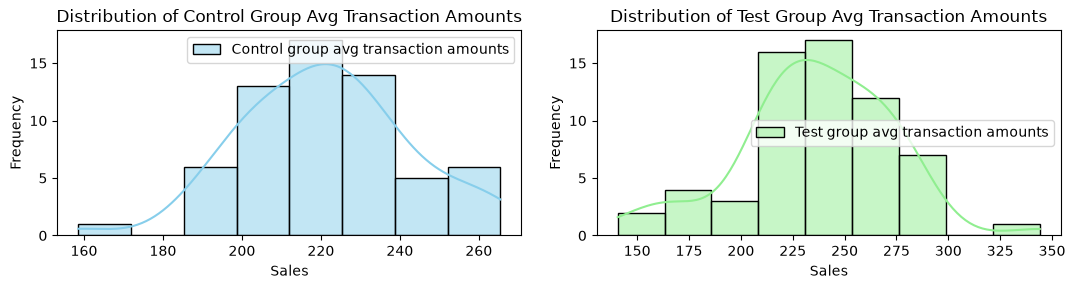

In [70]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(11,3))

sns.histplot(df["control_group_avg_tran"], kde=True, color = "skyblue", label = "Control group avg transaction amounts", ax=ax1)
ax1.set_xlabel("Sales")
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of Control Group Avg Transaction Amounts")
ax1.legend()


sns.histplot(df["test_group_avg_tran"], kde=True, color = "lightgreen", label='Test group avg transaction amounts', ax=ax2)
ax2.set_xlabel("Sales")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of Test Group Avg Transaction Amounts")
ax2.legend()
plt.tight_layout()
plt.show()

#### Calculating Mean and Standard Deviation

In [71]:
control_mean = df["control_group_avg_tran"].mean()
control_std = df["control_group_avg_tran"].std()

control_mean, control_std

(np.float64(221.1751612903226), np.float64(21.35919211202701))

In [72]:
test_mean = df["test_group_avg_tran"].mean()
test_std = df["test_group_avg_tran"].std()

test_mean, test_std

(np.float64(235.9835483870968), np.float64(36.658082109186374))

In [73]:
sample_size = df.shape[0]
sample_size

62

#### Calculating Standard Error

In [74]:
standard_error = np.sqrt(control_std**2/sample_size + test_std**2/sample_size)
standard_error

np.float64(5.3882040691087525)

#### Z Score

In [75]:
z_score = (test_mean - control_mean)/standard_error
z_score

np.float64(2.748297374569113)

#### Z Critical

In [76]:
alpha = 0.05
z_critical = st.norm.ppf(1-alpha)
z_critical

np.float64(1.6448536269514722)

In [77]:
z_score > z_critical

np.True_

##### The Z score is higher than the critical value, so I reject the null hypothesis. This suggests that the new credit card has a significantly higher average transaction amount than the existing card.

#### Calculating p-value

In [78]:
p_value = 1 - st.norm.cdf(z_score)
p_value

np.float64(0.0029952824622024865)

In [79]:
p_value < alpha

np.True_

##### The p-value is below 0.05, so I reject the null hypothesis. This supports the conclusion that the test group's average transaction amount is significantly higher than the control group.

### Using the Statsmodels Z-test

In [80]:
z_statistics, p_value = sm.stats.ztest(df["test_group_avg_tran"], df["control_group_avg_tran"], alternative = "larger")
z_statistics, p_value

(np.float64(2.7482973745691135), np.float64(0.002995282462202502))

### Further Analysis: Confidence Interval

In [81]:
test_group_CI = st.norm.interval(0.95, loc=test_mean, scale=test_std/np.sqrt(sample_size))
test_group_CI

(np.float64(226.85877713642867), np.float64(245.1083196377649))

##### The 95% confidence interval for the average transaction amount in the test group is approximately 227 to 245 dollars.